In [1]:
from cmb_lensing.simulate import *
from cmb_lensing.statistics import *
from cmb_lensing.util import *
from cmb_lensing.wiener_filter import *
from cmb_lensing.map_joint import *
from cmb_lensing.lense_flow import *
from cmb_lensing.gradients import *

The load_sim() method from the simulate sub-module allows the user to generate a data_set object which contains unlensed CMB temperature and polarization fields, the corresponding lensed fields, the lensing potential, "data" fields which represent the lensed fields with a mask and beam applied along with instrumental noise, and all the other covariance matrices and operators that will be necessary for CMB Lensing and field estimation.

In [2]:
#Generate an IP data set
data_set = load_sim(nside = 256, #Number of pixels per map side in real space
                    theta_pix = 2, #Arcminutes per pixel
                    pol = "IP", #Specify IP for temperature and E + B Modes, I for temp only, or P for E + B only
                    master_seed = 67, #Specify a seed for reproduceable results
                    uk_arcmin_t = 3) #Noise level in data fields

We can pick out the fields from the data_set object and then apply the lense_flow() algorithm on them which forward lenses the CMB maps

In [3]:
#select the fields from the data_set object
field = data_set.unlensed_field
phi = data_set.phi

#The fields default to Fourier space in the TEB parametrization
#but lense_flow requires converting to Map space in the TQU parametrization
field = map(eb2qu(field))
#The lensing potential has no polarization so we just need to take it to map space
phi = map(phi)

#The first input to lense flow is the field object to be lensed
#and the second input is the lensing potential
lensed_field = lense_flow(field, phi)

You can access the underlying data in the fields via the scalar_matrix, polar_matrix_1, and polar_matrix_2 attributes and plot them with standard matplotlib syntax. Here we plot the lensed temperature, polarization fields, and the lensing potential.

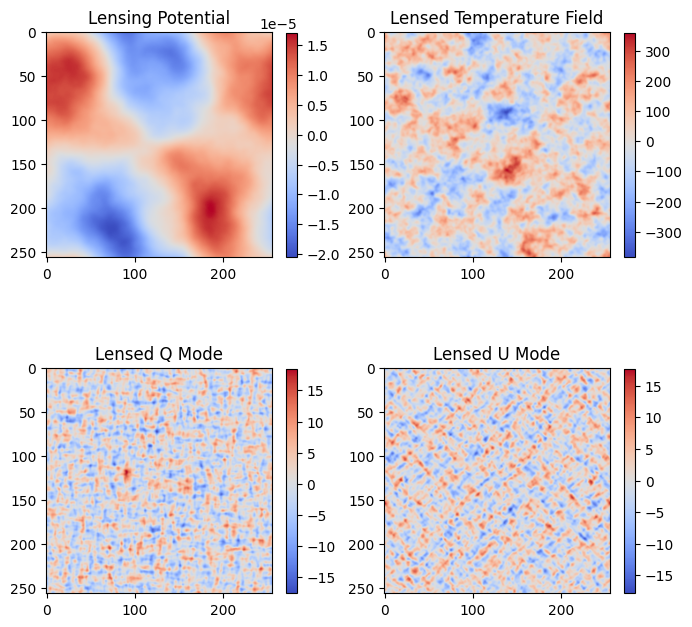

In [4]:
fig, axes = plt.subplots(2, 2, figsize = (8, 8))
im = axes[0][0].imshow(phi.scalar_matrix, cmap = "coolwarm")
fig.colorbar(im, ax = axes[0][0], shrink = 0.8)
axes[0][0].set_title("Lensing Potential")
im = axes[0][1].imshow(lensed_field.scalar_matrix, cmap = "coolwarm")
fig.colorbar(im, ax = axes[0][1], shrink = 0.8)
axes[0][1].set_title("Lensed Temperature Field")
im = axes[1][0].imshow(lensed_field.polar_matrix_1, cmap = "coolwarm")
fig.colorbar(im, ax = axes[1][0], shrink = 0.8)
axes[1][0].set_title("Lensed Q Mode")
im = axes[1][1].imshow(lensed_field.polar_matrix_2, cmap = "coolwarm")
fig.colorbar(im, ax = axes[1][1], shrink = 0.8)
axes[1][1].set_title("Lensed U Mode")
plt.show()

Even though the TQU parametrization is used for lensing, much of the work of CMBLensing.py is done in the TEB parametrization. Converting to the TQU parametrization requires first moving to Fourier space and then applying the qu2eb() method. Let's plot the corresponding lensed fields in the TEB Map space parametrization.

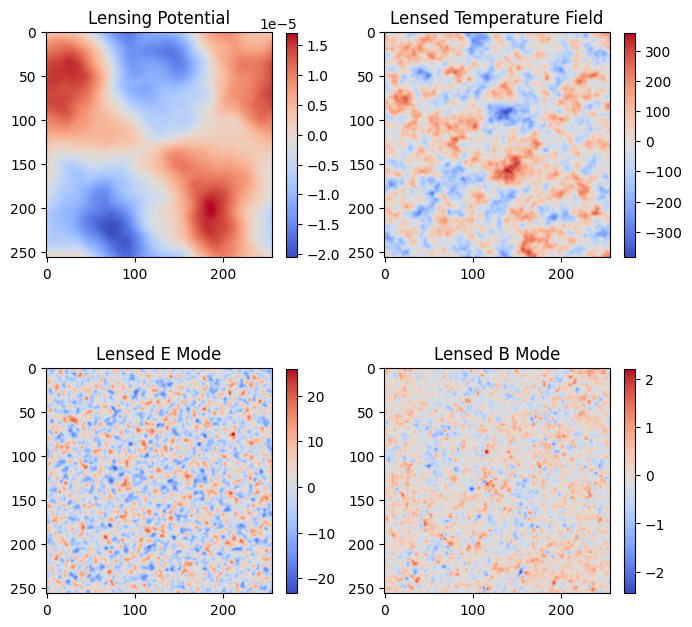

In [5]:
#Convert TQU in Map Space to TEB in MAP space by first stepping back to Fourier space
lensed_field = map(qu2eb(fourier(lensed_field)))
#Plot the results
fig, axes = plt.subplots(2, 2, figsize = (8, 8))
im = axes[0][0].imshow(phi.scalar_matrix, cmap = "coolwarm")
fig.colorbar(im, ax = axes[0][0], shrink = 0.8)
axes[0][0].set_title("Lensing Potential")
im = axes[0][1].imshow(lensed_field.scalar_matrix, cmap = "coolwarm")
fig.colorbar(im, ax = axes[0][1], shrink = 0.8)
axes[0][1].set_title("Lensed Temperature Field")
im = axes[1][0].imshow(lensed_field.polar_matrix_1, cmap = "coolwarm")
fig.colorbar(im, ax = axes[1][0], shrink = 0.8)
axes[1][0].set_title("Lensed E Mode")
im = axes[1][1].imshow(lensed_field.polar_matrix_2, cmap = "coolwarm")
fig.colorbar(im, ax = axes[1][1], shrink = 0.8)
axes[1][1].set_title("Lensed B Mode")
plt.show()

We can undo the lensing operation by simply setting the direction = INVERSE_LENSE flag and re-running lense_flow() on the already lensed field to recover the original input field. Behind the scenes, this amounts to just running the Diffrax ODE solver in reverse.

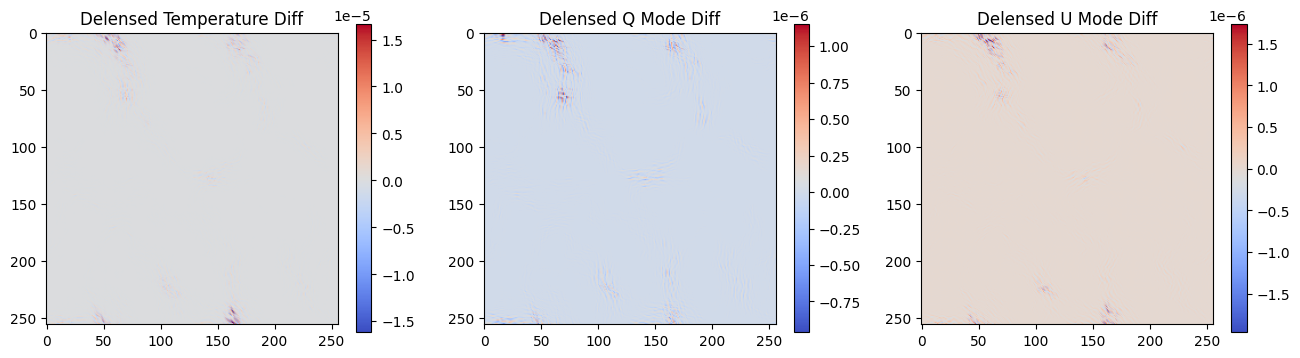

In [6]:
#Inverse lense the fields
lensed_field = map(eb2qu(fourier(lensed_field)))
delensed_field = lense_flow(lensed_field, phi, direction = INVERSE_LENSE)

#Then we can plot the difference between the delensed_field and the original input unlensed field
fig, axes = plt.subplots(1, 3, figsize = (16, 8))
im = axes[0].imshow(delensed_field.scalar_matrix - field.scalar_matrix, cmap = "coolwarm")
fig.colorbar(im, ax = axes[0], shrink = 0.5)
axes[0].set_title("Delensed Temperature Diff")
im = axes[1].imshow(delensed_field.polar_matrix_1 - field.polar_matrix_1, cmap = "coolwarm")
fig.colorbar(im, ax = axes[1], shrink = 0.5)
axes[1].set_title("Delensed Q Mode Diff")
im = axes[2].imshow(delensed_field.polar_matrix_2 - field.polar_matrix_2, cmap = "coolwarm")
fig.colorbar(im, ax = axes[2], shrink = 0.5)
axes[2].set_title("Delensed U Mode Diff")
plt.show()

In order to converge on accurately estimated lensing potentials and CMB fields, we need an objective function to minimize. The CMBLensing.py package does this by taking gradients of the logpdf function which takes the following mathematical form:

-2*logpdf = (data - M * B * L * f)^2/Cn + f^2/Cf + phi^2/Cphi + logdet(Cphi) + logdet(Cf) + logdet(Cn) 

In [7]:
#unpack the data from the data set object
field = data_set.unlensed_field
phi = data_set.phi
data = data_set.data
noise_covariance = data_set.noise_covariance
phi_covariance = data_set.phi_covariance
field_covariance = data_set.field_covariance
mask = data_set.mask
beam = data_set.beam

#use these fields to compute the logpdf
logpdf_value = logpdf(field, phi, data, noise_covariance, phi_covariance, field_covariance, mask, beam)
print(logpdf_value)

1373841.228394798


The main usefulness of the CMBLensing.py package is its map_joint() algorithm which takes in data fields and outputs the learned f and phi fields which maximize the logpdf. Let's try running this algorithm for 30 steps and then see how the learned fields compare to the ground truth simulated data.

In [8]:
#Run the MAP joint algorithm
#NOTE this may take up to 10 minutes for a 256 x 256 TEB dataset with the current state of the code
field_predict, phi_predict = map_joint(data_set, num_steps = 30)

The primal_cross_correlation function calculates the cross correlation between two CMB fields for a specific pixel resolution. Here we compare the cross correlation between the learned fields and the simulation ground truth.

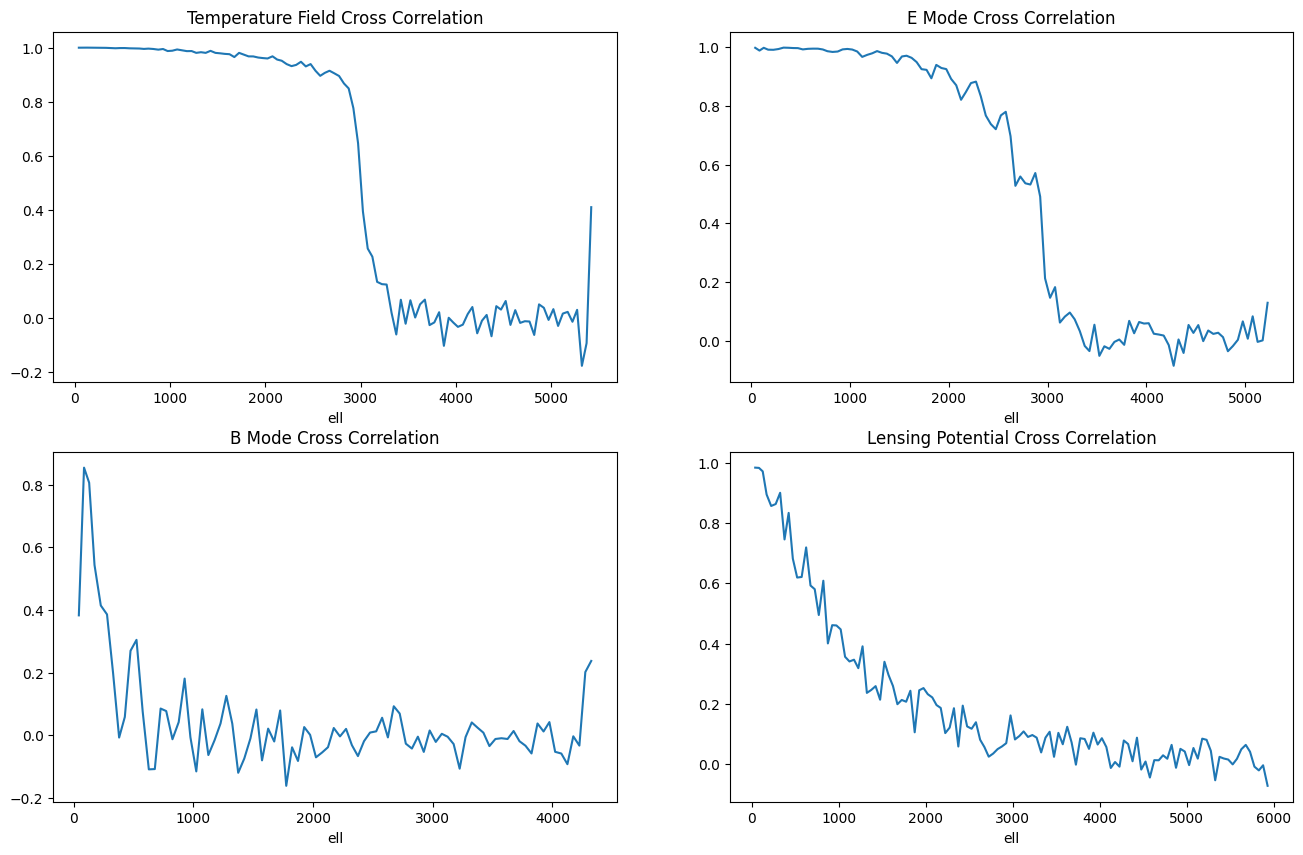

In [12]:
ell, cl_tt = primal_cross_correlation(field_predict.scalar_matrix, 
                                      data_set.unlensed_field.scalar_matrix, 
                                      data_set.unlensed_field.theta_pix)
_, cl_ee = primal_cross_correlation(field_predict.polar_matrix_1, 
                                    data_set.unlensed_field.polar_matrix_1, 
                                    data_set.unlensed_field.theta_pix)
_, cl_bb = primal_cross_correlation(field_predict.polar_matrix_2, 
                                    data_set.unlensed_field.polar_matrix_2, 
                                    data_set.unlensed_field.theta_pix)
_, cl_pp = primal_cross_correlation(phi_predict.scalar_matrix, 
                                    data_set.phi.scalar_matrix, 
                                    data_set.unlensed_field.theta_pix)
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
axes[0][0].plot(ell, cl_tt)
axes[0][0].set_title("Temperature Field Cross Correlation")
axes[0][0].set_xlabel("ell")
axes[0][1].plot(ell, cl_ee)
axes[0][1].set_title("E Mode Cross Correlation")
axes[0][1].set_xlabel("ell")
axes[1][0].plot(ell, cl_bb)
axes[1][0].set_title("B Mode Cross Correlation")
axes[1][0].set_xlabel("ell")
axes[1][1].plot(ell, cl_pp)
axes[1][1].set_title("Lensing Potential Cross Correlation")
axes[1][1].set_xlabel("ell")
plt.show()

We can also plot the matrix data and see how the learned fields visually compare to the ground truth

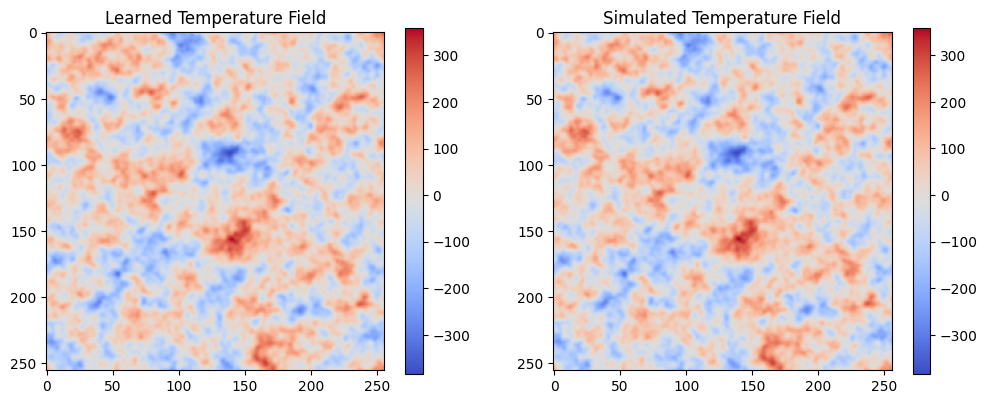

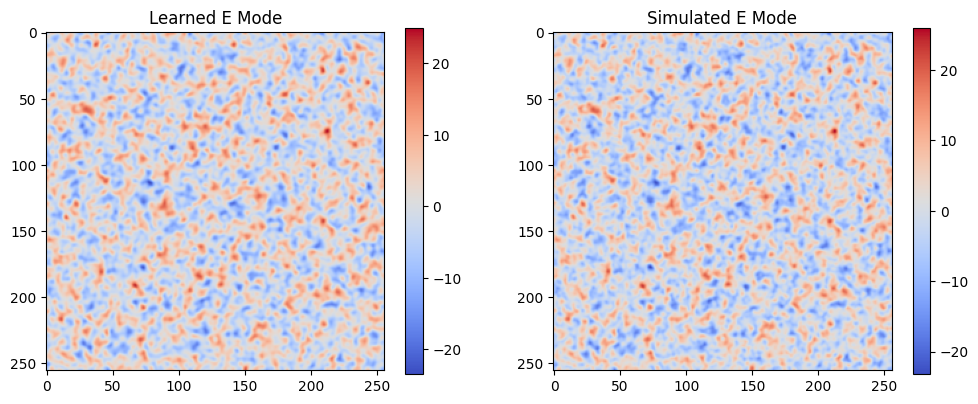

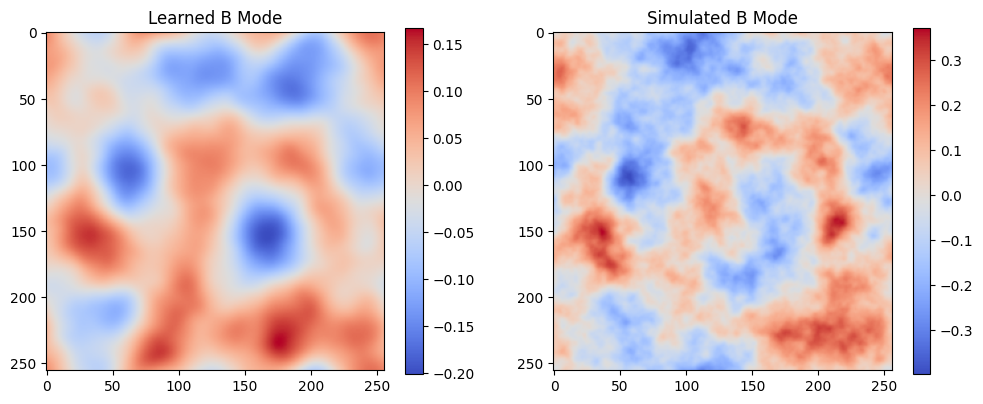

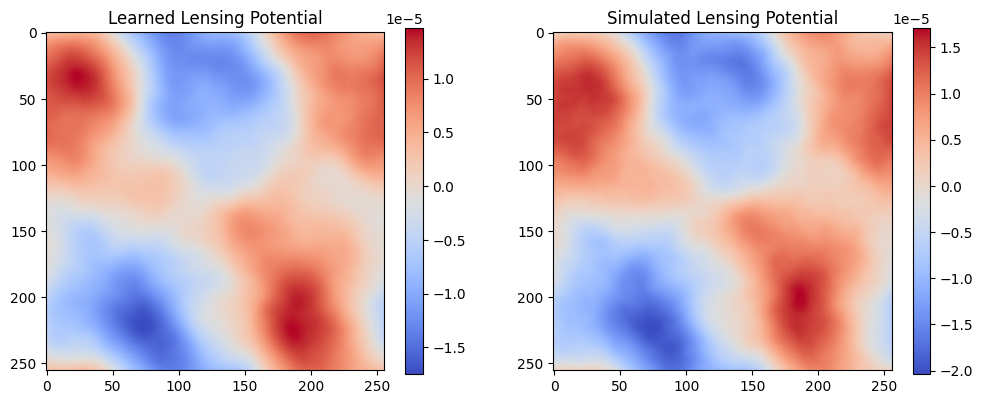

In [15]:
#Temperature comparison
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
im = axes[0].imshow(jfft.irfft2(field_predict.scalar_matrix), cmap = "coolwarm")
fig.colorbar(im, ax = axes[0], shrink = 0.75)
axes[0].set_title("Learned Temperature Field")
im = axes[1].imshow(jfft.irfft2(data_set.unlensed_field.scalar_matrix), cmap = "coolwarm")
fig.colorbar(im, ax = axes[1], shrink = 0.75)
axes[1].set_title("Simulated Temperature Field")
plt.show()

#E mode comparison
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
im = axes[0].imshow(jfft.irfft2(field_predict.polar_matrix_1), cmap = "coolwarm")
fig.colorbar(im, ax = axes[0], shrink = 0.75)
axes[0].set_title("Learned E Mode")
im = axes[1].imshow(jfft.irfft2(data_set.unlensed_field.polar_matrix_1), cmap = "coolwarm")
fig.colorbar(im, ax = axes[1], shrink = 0.75)
axes[1].set_title("Simulated E Mode")
plt.show()

#B mode comparison
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
im = axes[0].imshow(jfft.irfft2(field_predict.polar_matrix_2), cmap = "coolwarm")
fig.colorbar(im, ax = axes[0], shrink = 0.75)
axes[0].set_title("Learned B Mode")
im = axes[1].imshow(jfft.irfft2(data_set.unlensed_field.polar_matrix_2), cmap = "coolwarm")
fig.colorbar(im, ax = axes[1], shrink = 0.75)
axes[1].set_title("Simulated B Mode")
plt.show()

#Lensing potential comparison
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
im = axes[0].imshow(jfft.irfft2(phi_predict.scalar_matrix), cmap = "coolwarm")
fig.colorbar(im, ax = axes[0], shrink = 0.75)
axes[0].set_title("Learned Lensing Potential")
im = axes[1].imshow(jfft.irfft2(data_set.phi.scalar_matrix), cmap = "coolwarm")
fig.colorbar(im, ax = axes[1], shrink = 0.75)
axes[1].set_title("Simulated Lensing Potential")
plt.show()